# Jokes clustering and classification using SBERT

Antoine de Chabannes Curton la Palice, Hugo Viana

## Abstract

l'abstract ici

In [2]:
# Dependencies

!pip install sentence-transformers
import os
import numpy as np
import pandas as pd
import kagglehub
from sentence_transformers import SentenceTransformer
from tqdm import tqdm

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize

# NN classifier
import torch
import torch.nn as nn
import lightning as L
import torchmetrics
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 1. Introduction

### 1.1 Research Question

Nous étudions si des blagues peuvent être automatiquement regroupées et classifiées à partir de leurs propriétés linguistiques.

En observant le jeu de données, on constate que les blagues présentent des variations de thèmes (politique relations, religion, etc.) ainsi que des structures linguistiques différentes (question-réponse, narration, jeux de mots). 
Nous faisons l’hypothèse que ces différences peuvent être capturées par :

- les mots fréquents (information lexicale),
- les structures morpho-syntaxiques,
- les représentations vectorielles (embeddings).

Nous voulons mesurer dans quelle mesure ces informations permettent :

1. d’identifier des groupes cohérents de blagues via du clustering.
2. d’entraîner un modèle supervisé capable de prédire la catégorie d’une blague.

### 1.2 Réflexion

Cette tâche n’est pas triviale, car l’humour repose sur des éléments implicites ou contextuels (ironie, double sens, références culturelles) qui ne sont pas toujours capturés par les mots seuls. De plus, certaines blagues peuvent appartenir à plusieurs catégories ou être ambiguës.

Notre hypothèse serait invalidée si :
- les clusters obtenus ne sont pas interprétables linguistiquement ;
- les performances du modèle de classification restent proches d’une baseline simple.


## 2. Data & Preprocessing

### 2.1 Dataset Selection

#### Source
Nous utilisons le dataset **Short Jokes Dataset** disponible sur la plateforme Kaggle, contenant plus de 200 000 blagues courtes en anglais, collectées en ligne, principalement issues de forums et de réseaux sociaux.. 
Lien : https://www.kaggle.com/datasets/abhinavmoudgil95/short-jokes/data

#### Domaine
Le corpus appartient au domaine de l’humour informel et couvre plusieurs thématiques : relations, politique, religion, vie quotidienne, jeux de mots, etc. Les blagues sont généralement assez courtes et souvent basées sur des structures linguistiques simples (question-réponse, punchline).

#### Labels
Le dataset original ne contient pas de labels. Afin de construire une tâche de classification, nous générons des catégories à partir d’un clustering non supervisé, suivi d’une interprétation manuelle des groupes obtenus. Cela nous permet d’obtenir l'ensemble du dataset annotées.

#### Biais potentiels
Le dataset présente plusieurs biais :
- biais culturel (humour anglophone, références spécifiques) ;
- biais thématique (certains sujets plus fréquents) ;
- biais de style (blagues très courtes, langage informel).

Ces biais peuvent influencer les performances des modèles et limiter la généralisation.

#### Considérations éthiques
Certaines blagues peuvent contenir du contenu offensant, discriminatoire ou sensible (religion, genre, origine). Cela pose des questions d’éthique dans l’utilisation et l’interprétation des résultats.

In [3]:
# Chargement du dataset
import pandas as pd
import os
import kagglehub

# Download dataset latest version
path = kagglehub.dataset_download("abhinavmoudgil95/short-jokes")

df = pd.read_csv(os.path.join(path, "shortjokes.csv"))

print("Nb jokes :", len(df))

n = 5
print("\nExample of ", n, " jokes : ")
for i in range(n):
    print(i+1, ":", df['Joke'].iloc[i])




Nb jokes : 231657

Example of  5  jokes : 
1 : [me narrating a documentary about narrators] "I can't hear what they're saying cuz I'm talking"
2 : Telling my daughter garlic is good for you. Good immune system and keeps pests away.Ticks, mosquitos, vampires... men.
3 : I've been going through a really rough period at work this week It's my own fault for swapping my tampax for sand paper.
4 : If I could have dinner with anyone, dead or alive... ...I would choose alive. -B.J. Novak-
5 : Two guys walk into a bar. The third guy ducks.


### 2.2 Data Split

Nous divisons les données en trois ensembles :

- **Train            : 70%**
- **Validation (Dev) : 10%**
- **Test             : 20%**

Ce choix permet :
- d’entraîner les modèles sur une grande quantité de données,
- d’optimiser les hyperparamètres sur le jeu de validation,
- d’évaluer les performances finales sur un jeu de test indépendant.

La reproductibilité est assurée en fixant une graine aléatoire (`random_state=42`).

### 2.3 Preprocessing Strategy



La longueur des blagues (en nombre de caractères) présente les caractéristiques suivantes :

- moyenne : 93  
- médiane : 88  
- minimum : 10  
- maximum : 200  

La distribution est relativement concentrée, avec une majorité de blagues courtes (entre 66 et 119 caractères). Cela confirme que le dataset est composé de textes très courts, ce qui influence le choix des méthodes de représentation.

En particulier :
- les modèles basés sur TF-IDF peuvent être efficaces car les textes sont courts et peu ambigus lexicalement.
- les modèles contextuels (embeddings) peuvent néanmoins capturer des similarités sémantiques plus fines.

Cette courte longueur limite cependant la quantité d’information disponible, ce qui rend la tâche de classification plus difficile.

#### Tokenization
Nous utilisons une tokenisation au niveau des mots (word-level) via TF-IDF.
Cette approche est adaptée à des textes courts comme les blagues, où les mots individuels et les n-grammes capturent des motifs fréquents.

#### Stopwords
Nous ne supprimons pas les stopwords.
Car dans le cas des blagues, certains mots fréquents (ex. "why", "what") participent à des structures humoristiques. 

#### Lemmatisation vs Stemming
Nous n’appliquons ni lemmatisation ni stemming. 
Cela permet de conserver les formes originales des mots, ce qui est important pour préserver le sens et les jeux de mots.

#### Rare words filtering
Nous filtrons les mots rares avec `min_df=2` afin de réduire le bruit.
Nous limitons également le vocabulaire à 5000 termes (`max_features=5000`) pour contrôler la dimensionnalité.

#### Frequent words filtering
Nous utilisons `max_df=0.95` pour éliminer les mots trop fréquents, peu informatifs.

#### N-grams
Nous utilisons des unigrammes et bigrammes (`ngram_range=(1,2)`), ce qui permet de capturer des expressions fréquentes comme "knock knock" ou "yo mama".

#### Embeddings (SBERT)
Nous utilisons le modèle :contentReference[oaicite:0]{index=0} pour obtenir des représentations sémantiques des phrases.
Ce modèle repose sur une tokenisation subword interne (WordPiece), permettant de gérer les mots rares.

#### Normalisation
Les vecteurs TF-IDF et SBERT sont normalisés (norme L2) afin de rendre les distances comparables.

#### Fusion des représentations
Nous combinons les embeddings sémantiques (SBERT) et les représentations lexicales (TF-IDF) 

Cette fusion permet de capturer à la fois :
- la similarité sémantique globale
- les motifs lexicaux spécifiques

### 2.2. Jokes embedding

Embedding avec SBERT

In [30]:
import numpy as np
from tqdm.auto import tqdm
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
import pickle

SEED = 42
N_SAMPLES = 10000

tqdm.write("Step 1/2 - Sampling...")
df_combined = df.sample(n=min(N_SAMPLES, len(df)), random_state=SEED).reset_index(drop=True)

tqdm.write("Step 2/2 - SBERT embeddings...")
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
X_sbert = normalize(
    model.encode(df_combined["Joke"].tolist(), batch_size=32, show_progress_bar=True),
    norm="l2"
)

with open("embeddings_sbert.pkl", "wb") as f:
    pickle.dump({"X_sbert": X_sbert, "df": df_combined}, f)

print(f"Sauvegardé : X_sbert shape = {X_sbert.shape}")

Step 1/2 - Sampling...
Step 2/2 - SBERT embeddings...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Sauvegardé : X_sbert shape = (10000, 384)


  0%|          | 0/38 [00:00<?, ?it/s]

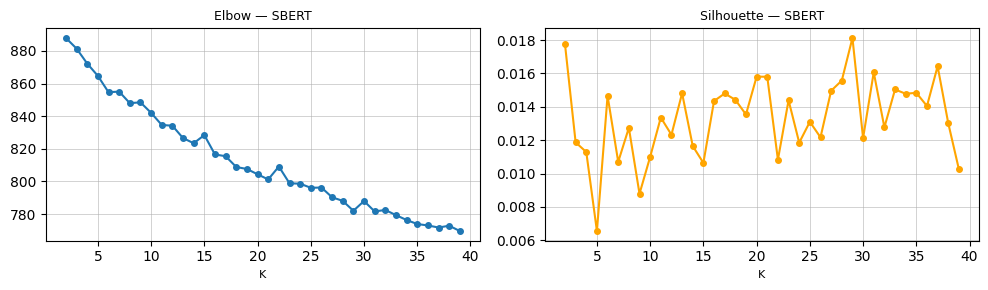

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from tqdm.auto import tqdm
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

with open("embeddings_sbert.pkl", "rb") as f:
    data = pickle.load(f)
X_sbert = data["X_sbert"]

SEED = 42
K_values = range(2, 40)
X = X_sbert

idx = np.random.default_rng(SEED).choice(X.shape[0], size=1000, replace=False)
X_sub = X[idx]
inertias, sil_scores = [], []

for k in tqdm(K_values):
    km = MiniBatchKMeans(n_clusters=k, random_state=SEED, n_init=10)
    lbl = km.fit_predict(X_sub)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sub, lbl))

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(K_values, inertias, marker="o", markersize=4)
axes[0].set_title("Elbow — SBERT", fontsize=9); axes[0].set_xlabel("K", fontsize=8); axes[0].grid(True, linewidth=0.4)
axes[1].plot(K_values, sil_scores, marker="o", markersize=4, color="orange")
axes[1].set_title("Silhouette — SBERT", fontsize=9); axes[1].set_xlabel("K", fontsize=8); axes[1].grid(True, linewidth=0.4)
plt.tight_layout(); plt.show()


[SBERT] Silhouette: 0.0158 | Davies-Bouldin: 5.1721


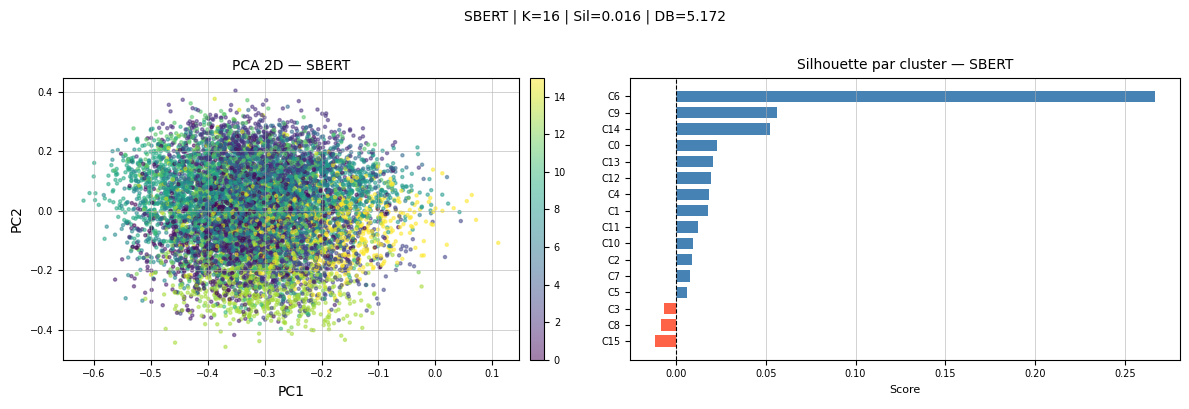

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score, davies_bouldin_score, silhouette_samples

with open("embeddings_sbert.pkl", "rb") as f:
    data = pickle.load(f)
X_sbert = data["X_sbert"]
df_combined = data["df"]

SEED = 42
K_FINAL = 16
X = X_sbert

kmeans = KMeans(n_clusters=K_FINAL, init="k-means++", n_init=10, random_state=SEED)
labels = kmeans.fit_predict(X)
df_combined["label_sbert"] = labels

sil = silhouette_score(X, labels, sample_size=2000, random_state=SEED)
db  = davies_bouldin_score(X, labels)
print(f"\n[SBERT] Silhouette: {sil:.4f} | Davies-Bouldin: {db:.4f}")

X_2d = TruncatedSVD(n_components=2, random_state=SEED).fit_transform(X)
sil_vals = silhouette_samples(X, labels)
cluster_scores = {k: sil_vals[labels == k].mean() for k in range(K_FINAL)}
sorted_clusters = sorted(cluster_scores, key=cluster_scores.get)
scores = [cluster_scores[k] for k in sorted_clusters]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sc = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=labels, s=5, alpha=0.5)
axes[0].set_title("PCA 2D — SBERT", fontsize=10); axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].tick_params(labelsize=7); axes[0].grid(True, linewidth=0.4)
plt.colorbar(sc, ax=axes[0], pad=0.02).ax.tick_params(labelsize=7)
axes[1].barh(range(K_FINAL), scores, color=["tomato" if s < 0 else "steelblue" for s in scores], height=0.7)
axes[1].set_yticks(range(K_FINAL)); axes[1].set_yticklabels([f"C{k}" for k in sorted_clusters], fontsize=6)
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Silhouette par cluster — SBERT", fontsize=10); axes[1].set_xlabel("Score", fontsize=8)
axes[1].tick_params(labelsize=7); axes[1].grid(True, axis="x", linewidth=0.4)
plt.suptitle(f"SBERT | K={K_FINAL} | Sil={sil:.3f} | DB={db:.3f}", fontsize=10, y=1.01)
plt.tight_layout(); plt.show()

import pickle
with open("clusters_sbert.pkl", "wb") as f:
    pickle.dump({"X": X, "labels": labels, "kmeans": kmeans, "df": df_combined}, f)

In [33]:
import numpy as np
import pickle
from sklearn.metrics import silhouette_samples

with open("clusters_sbert.pkl", "rb") as f:
    data = pickle.load(f)
X, labels, kmeans, df_combined = data["X"], data["labels"], data["kmeans"], data["df"]

K_FINAL = 16
distances_to_centroids = kmeans.transform(X)
sil_vals = silhouette_samples(X, labels)

for cluster_id in range(K_FINAL):
    cluster_indices = np.where(labels == cluster_id)[0]
    cluster_score = sil_vals[cluster_indices].mean()
    cluster_distances = distances_to_centroids[cluster_indices, cluster_id]
    closest_indices = cluster_indices[np.argsort(cluster_distances)[:5]]

    print("\n" + "=" * 80)
    print(f"CLUSTER {cluster_id} | size = {len(cluster_indices)} | score = {cluster_score:.4f}")
    for idx in closest_indices:
        print("-", df_combined.iloc[idx]["Joke"])


CLUSTER 0 | size = 777 | score = 0.0231
- What is a pedophiles favorite Italian meal? Chicken Statutory....I'm going, I'm going...sorry but this is how my brain works before I've had coffee.
- "This soup was so good I wish I could just...NOMCRNCHNCH" *chewing glass* "There must be a better way!" -Inventing the bread bowl
- What do dumbfounded people eat for desert? Geezcake
- What do you call a vegetarian with diarrhea? A salad shooter
- Why do people with bulimia nervosa love KFC? Because your meal comes with a bucket!

CLUSTER 1 | size = 634 | score = 0.0181
- I saw a woman texting and driving today and it really pissed me off... So I rolled down my window and threw my beer at her.
- I saw a girl texting and driving earlier today and it really pissed me off... So I rolled my window down and threw my beer at her.
- I walked in on my parents having sex last night... Possibly the most awkward 45 minutes of my life...
- Accidentally ran over my neighbor's cat today and I was scared to t

In [ ]:
import numpy as np
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

SVD_DIM = 150
SEED = 42

with open("embeddings_sbert.pkl", "rb") as f:
    data = pickle.load(f)
X_sbert = data["X_sbert"]
df_combined = data["df"]

print("TF-IDF + SVD...")
vectorizer = TfidfVectorizer(lowercase=False, max_features=5000, ngram_range=(1, 4), max_df=0.95)
X_tfidf = vectorizer.fit_transform(df_combined["Joke"])
svd = TruncatedSVD(n_components=SVD_DIM, random_state=SEED)
X_tfidf_r = normalize(svd.fit_transform(X_tfidf), norm="l2")
print(f"Variance expliquée : {svd.explained_variance_ratio_.sum():.2%}")

X_combined = np.hstack([X_sbert, X_tfidf_r])
print(f"Combined shape : {X_combined.shape}")

with open("embeddings_combined.pkl", "wb") as f:
    pickle.dump({"X_combined": X_combined, "df": df_combined}, f)

print("Sauvegardé : embeddings_combined.pkl")

TF-IDF + SVD...
Variance expliquée : 28.67%
Combined shape : (10000, 534)
       ID                                               Joke  \
0    4511  What do all battered women have in common? The...   
1  161745  Who invented the North America? TEACHER: Sarah...   
2  155604  I feel like this election ended up being a goo...   
3  100594    What do you call a pile of kittens? A Meowntain   
4   23209  I feel bad for people named John Smith. They p...   

                                           embedding  
0  [0.07385389506816864, -0.04534558951854706, -0...  
1  [0.004899713676422834, 0.03203880786895752, 0....  
2  [-0.004624907858669758, -0.019848790019750595,...  
3  [-0.019022546708583832, -0.012466602958738804,...  
4  [-0.1310558170080185, 0.005039885174483061, 0....  
Sauvegardé : embeddings_combined.pkl


  0%|          | 0/38 [00:00<?, ?it/s]

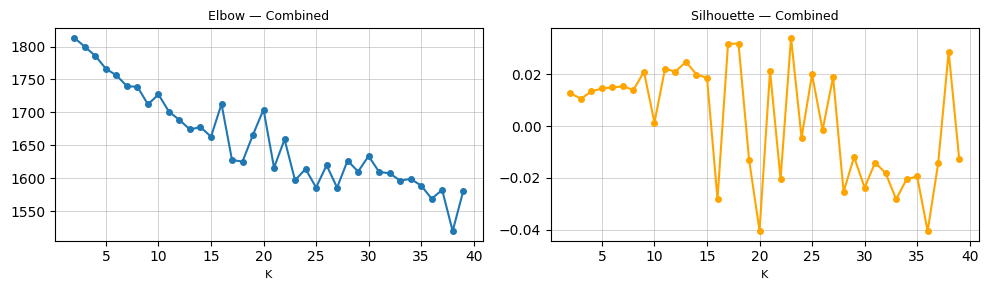

In [60]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from tqdm.auto import tqdm
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

with open("embeddings_combined.pkl", "rb") as f:
    data = pickle.load(f)
X = data["X_combined"]

SEED = 42
K_values = range(2, 40)

idx = np.random.default_rng(SEED).choice(X.shape[0], size=1000, replace=False)
X_sub = X[idx]
inertias, sil_scores = [], []

for k in tqdm(K_values):
    km = MiniBatchKMeans(n_clusters=k, random_state=SEED, n_init=10)
    lbl = km.fit_predict(X_sub)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sub, lbl))

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(K_values, inertias, marker="o", markersize=4)
axes[0].set_title("Elbow — Combined", fontsize=9); axes[0].set_xlabel("K", fontsize=8); axes[0].grid(True, linewidth=0.4)
axes[1].plot(K_values, sil_scores, marker="o", markersize=4, color="orange")
axes[1].set_title("Silhouette — Combined", fontsize=9); axes[1].set_xlabel("K", fontsize=8); axes[1].grid(True, linewidth=0.4)
plt.tight_layout(); plt.show()


[Combined] Silhouette: 0.0318 | Davies-Bouldin: 4.9649


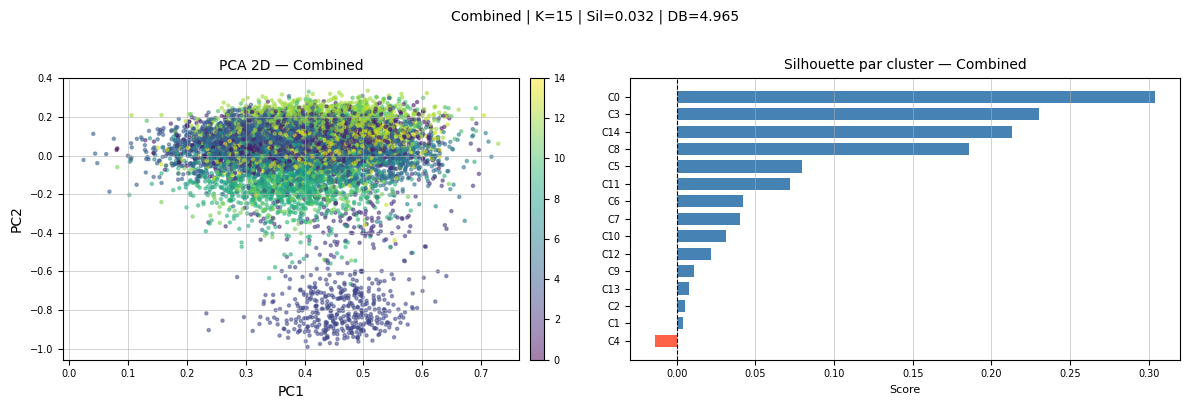

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score, davies_bouldin_score, silhouette_samples

with open("embeddings_combined.pkl", "rb") as f:
    data = pickle.load(f)
X = data["X_combined"]
df_combined = data["df"]

SEED = 42
K_FINAL = 15

kmeans = KMeans(n_clusters=K_FINAL, init="k-means++", n_init=10, random_state=SEED)
labels = kmeans.fit_predict(X)
df_combined["label"] = labels

sil = silhouette_score(X, labels, sample_size=2000, random_state=SEED)
db  = davies_bouldin_score(X, labels)
print(f"\n[Combined] Silhouette: {sil:.4f} | Davies-Bouldin: {db:.4f}")

X_2d = TruncatedSVD(n_components=2, random_state=SEED).fit_transform(X)
sil_vals = silhouette_samples(X, labels)
cluster_scores = {k: sil_vals[labels == k].mean() for k in range(K_FINAL)}
sorted_clusters = sorted(cluster_scores, key=cluster_scores.get)
scores = [cluster_scores[k] for k in sorted_clusters]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sc = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=labels, s=5, alpha=0.5)
axes[0].set_title("PCA 2D — Combined", fontsize=10); axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].tick_params(labelsize=7); axes[0].grid(True, linewidth=0.4)
plt.colorbar(sc, ax=axes[0], pad=0.02).ax.tick_params(labelsize=7)
axes[1].barh(range(K_FINAL), scores, color=["tomato" if s < 0 else "steelblue" for s in scores], height=0.7)
axes[1].set_yticks(range(K_FINAL)); axes[1].set_yticklabels([f"C{k}" for k in sorted_clusters], fontsize=6)
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Silhouette par cluster — Combined", fontsize=10); axes[1].set_xlabel("Score", fontsize=8)
axes[1].tick_params(labelsize=7); axes[1].grid(True, axis="x", linewidth=0.4)
plt.suptitle(f"Combined | K={K_FINAL} | Sil={sil:.3f} | DB={db:.3f}", fontsize=10, y=1.01)
plt.tight_layout(); plt.show()

with open("clusters_combined.pkl", "wb") as f:
    pickle.dump({"X": X, "labels": labels, "kmeans": kmeans, "df": df_combined}, f)

In [154]:
import numpy as np
import pickle
from sklearn.metrics import silhouette_samples

with open("clusters_combined.pkl", "rb") as f:
    data = pickle.load(f)
X, labels, kmeans, df_combined = data["X"], data["labels"], data["kmeans"], data["df"]

K_FINAL = 15
distances_to_centroids = kmeans.transform(X)
sil_vals = silhouette_samples(X, labels)

for cluster_id in range(K_FINAL):
    cluster_indices = np.where(labels == cluster_id)[0]
    cluster_score = sil_vals[cluster_indices].mean()
    closest_indices = cluster_indices[np.argsort(distances_to_centroids[cluster_indices, cluster_id])[:10]]

    print("\n" + "=" * 80)
    print(f"CLUSTER {cluster_id} | size = {len(cluster_indices)} | score = {cluster_score:.4f}")
    for idx in closest_indices:
        print("-", df_combined.iloc[idx]["Joke"])

df_combined.to_pickle("clusters_combined_final.pkl")


CLUSTER 0 | size = 128 | score = 0.3040
- How many germans does it take to change a lightbulb? One.
- How many Russians does it take to change a lightbulb? Two. One to hold the bulb and other to drink until the room spins.
- How many Alzheimer's patients does it take to screw on a light bulb? TO GET TO THE OTHER SIDE!
- How many gays does it take to put in a lightbulb? Only one, but it takes a whole emergency room to remove it.
- How many perverts does it take to put in a light bulb? Just the two... but it takes a whole dedicated team at emergency to remove it.
- How many idiots does it take to change a light bulb? Five - one to hold the bulb, and four to turn his ladder
- How many extroverts does it take to change a lightbulb? Let's throw a party while we're at it.
- How many redditors does it take to change a light bulb.? Three. One to screw it in and the second to take credit for it. And the other to repeat it.
- How many men does it take to change a light bulb? Not all of them.
- 

In [155]:
import re

def detect_structure(joke):
    j = joke.lower().strip()

    if re.search(r"how many .{2,40} (take|takes|does it take|screw|put|change)", j):
        return "Lightbulb"
    if re.search(r"did you hear (about|the)", j):
        return "DidYouHear"
    if re.search(r"what'?s? the difference between", j):
        return "WhatsDifference"
    if re.search(r"(walks?|walked) into (a|the) bar", j):
        return "WalkedIntoBar"
    if re.search(r"what do you call (a|an|the)", j):
        return "WhatDoYouCall"
    if re.search(r"what did (the|a|an)?.{1,30} say", j):
        return "WhatDidXSay"
    if re.search(r"^why do(es|n'?t)?", j):
        return "WhyDo"
    if re.search(r"^how do(es|n'?t)? (you|a|an)", j):
        return "HowDoYou"
    if re.search(r"^what (is|are|was|were) (a|an|the|your)?", j):
        return "WhatIs"
    if re.search(r"^(me|wife|husband|her|him|mom|dad|boss|friend|sex)\s*:", j):
        return "Dialogue"

    return None  # pas de structure détectée


# ── Seuil : au moins X% du cluster doit matcher ──────────────────────────────
THRESHOLD = 0.10  # 10% minimum
from collections import Counter

cluster_label_map = {}

for cluster_id in sorted(df_combined["label"].unique()):
    jokes = df_combined[df_combined["label"] == cluster_id]["Joke"].tolist()
    n = len(jokes)

    counts = Counter()
    for joke in jokes:
        structure = detect_structure(joke)
        if structure:
            counts[structure] += 1

    # Label dominant seulement si > THRESHOLD
    if counts:
        top_label, top_count = counts.most_common(1)[0]
        if top_count / n >= THRESHOLD:
            cluster_label_map[cluster_id] = top_label
        else:
            cluster_label_map[cluster_id] = "Other"
    else:
        cluster_label_map[cluster_id] = "Other"

# ── Appliquer + afficher ──────────────────────────────────────────────────────
df_combined["label_name"] = df_combined["label"].map(cluster_label_map)

for cluster_id, label_name in sorted(cluster_label_map.items()):
    size = (df_combined["label"] == cluster_id).sum()
    print(f"CLUSTER {cluster_id:>2} | size={size:>4} | {label_name}")

CLUSTER  0 | size= 128 | Lightbulb
CLUSTER  1 | size= 863 | Other
CLUSTER  2 | size= 922 | Other
CLUSTER  3 | size= 421 | WhatDoYouCall
CLUSTER  4 | size=2498 | Other
CLUSTER  5 | size= 524 | WhatDidXSay
CLUSTER  6 | size= 545 | WalkedIntoBar
CLUSTER  7 | size= 511 | WhyDo
CLUSTER  8 | size= 241 | WhatsDifference
CLUSTER  9 | size= 715 | WhatIs
CLUSTER 10 | size= 584 | Other
CLUSTER 11 | size= 266 | HowDoYou
CLUSTER 12 | size= 896 | Other
CLUSTER 13 | size= 730 | Dialogue
CLUSTER 14 | size= 156 | DidYouHear


In [156]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

noise_cluster = df_combined["label"].value_counts().idxmax()

other_clusters = [
    cid for cid, lbl in cluster_label_map.items()
    if lbl == "Other"
]

vec = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=10000,
    ngram_range=(1, 2),
    max_df=0.95,
    min_df=3
)
X_terms = vec.fit_transform(df_combined["Joke"])
terms = np.array(vec.get_feature_names_out())
global_mean = np.asarray(X_terms.mean(axis=0)).flatten()

for cluster_id in sorted(other_clusters):
    mask = df_combined["label"].values == cluster_id
    cluster_mean = np.asarray(X_terms[mask].mean(axis=0)).flatten()
    diff = cluster_mean - global_mean
    top_idx = diff.argsort()[::-1][:15]
    top_words = terms[top_idx].tolist()

    size = mask.sum()
    print(f"\nCLUSTER {cluster_id:>2} | size={size:>4}")
    print(f"  {', '.join(top_words)}")


CLUSTER  1 | size= 863
  said, got, went, day, friend, asked, saw, told, died, couldn, today, happened, thought, guy, dad

CLUSTER  2 | size= 922
  know, cross, don, want, tell, like, remember, throw, ask, sorry, unless, thank, ve, yes, mean

CLUSTER  4 | size=2498
  people, just, new, world, trump, women, called, think, like, lot, way, don, life, ve, good

CLUSTER 10 | size= 584
  girlfriend, wife, girl, said, woman, told, asked, yo, fat, mama, yo mama, got, mom, daughter, old

CLUSTER 12 | size= 896
  like, like like, just, like women, women like, ve, body, women, really, got, life, today, like coffee, phone, friends


In [167]:
def assign_label_from_terms(top_words):

    if any(t in top_words for t in ["girlfriend", "wife", "yo mama", "mama", "fat", "woman", "daughter"]):
        return "Relationship"

    if any(t in top_words for t in ["like like", "like women", "women like", "like coffee", "body", "friends"]):
        return "Anecdote"

    if any(t in top_words for t in ["know", "don", "want", "tell", "remember", "sorry", "mean", "cross"]):
        return "Observational"

    if any(t in top_words for t in ["said", "went", "told", "asked", "saw", "happened", "thought", "today", "died"]):
        return "Other"

    return "Other"


# ── Application sur les clusters Other ───────────────────────────────────────
for cluster_id in sorted(other_clusters + [noise_cluster]):
    mask = df_combined["label"].values == cluster_id
    size = mask.sum()

    if size > 2000:
        cluster_label_map[cluster_id] = "Noise"
        continue

    cluster_mean = np.asarray(X_terms[mask].mean(axis=0)).flatten()
    diff = cluster_mean - global_mean
    top_idx = diff.argsort()[::-1][:15]
    top_words = terms[top_idx].tolist()

    cluster_label_map[cluster_id] = assign_label_from_terms(top_words)

df_combined["label_name"] = df_combined["label"].map(cluster_label_map)

print("── Résultat final ───────────────────────────────────────────────────")
for cluster_id, label_name in sorted(cluster_label_map.items()):
    size = (df_combined["label"] == cluster_id).sum()
    print(f"CLUSTER {cluster_id:>2} | size={size:>4} | {label_name}")

── Résultat final ───────────────────────────────────────────────────
CLUSTER  0 | size= 128 | Lightbulb
CLUSTER  1 | size= 863 | Other
CLUSTER  2 | size= 922 | Observational
CLUSTER  3 | size= 421 | WhatDoYouCall
CLUSTER  4 | size=2498 | Noise
CLUSTER  5 | size= 524 | WhatDidXSay
CLUSTER  6 | size= 545 | WalkedIntoBar
CLUSTER  7 | size= 511 | WhyDo
CLUSTER  8 | size= 241 | WhatsDifference
CLUSTER  9 | size= 715 | WhatIs
CLUSTER 10 | size= 584 | Relationship
CLUSTER 11 | size= 266 | HowDoYou
CLUSTER 12 | size= 896 | Anecdote
CLUSTER 13 | size= 730 | Dialogue
CLUSTER 14 | size= 156 | DidYouHear


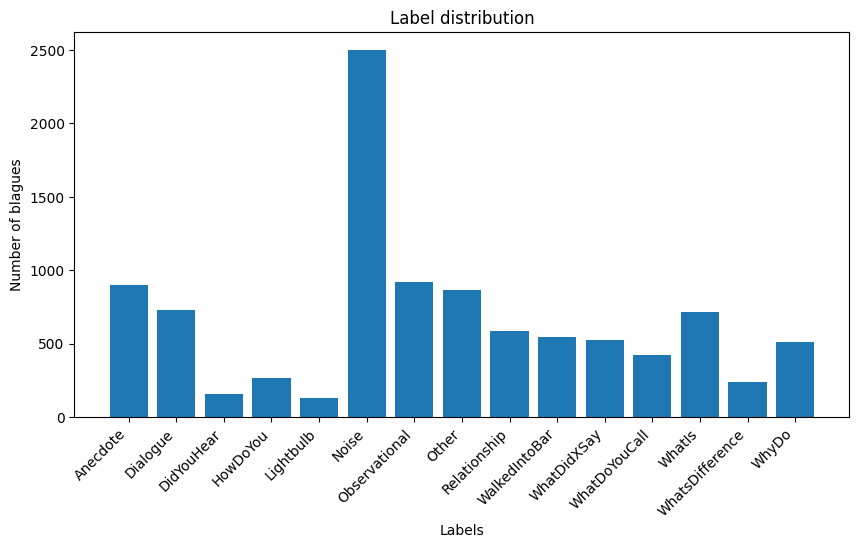

In [164]:
import matplotlib.pyplot as plt

# compter les clusters
cluster_counts = df_combined["label_name"].value_counts().sort_index()

# plot
plt.figure(figsize=(10, 5))
plt.bar(cluster_counts.index, cluster_counts.values)

plt.xlabel("Labels")
plt.ylabel("Number of blagues")
plt.title("Label distribution")
plt.xticks(rotation=45, ha="right")

plt.show()

In [ ]:
# Ajout des embeddings combinés au DataFrame pour la classification supervisée
df_combined["embedding"] = list(X_combined)
df_combined.head()

,ID,Joke,label,label_name,embedding,embedding_combined
0,4511,What do all battered women have in common? The...,9,WhatIs,"[0.07385389506816864, -0.04534558951854706, -0...","[0.07385389506816864, -0.04534558951854706, -0..."
1,161745,Who invented the North America? TEACHER: Sarah...,4,Noise,"[0.004899713676422834, 0.03203880786895752, 0....","[0.004899713676422834, 0.03203880786895752, 0...."
2,155604,I feel like this election ended up being a goo...,4,Noise,"[-0.004624907858669758, -0.019848790019750595,...","[-0.004624907858669758, -0.019848790019750595,..."
3,100594,What do you call a pile of kittens? A Meowntain,3,WhatDoYouCall,"[-0.019022546708583832, -0.012466602958738804,...","[-0.019022546708583832, -0.012466602958738804,..."
4,23209,I feel bad for people named John Smith. They p...,4,Noise,"[-0.1310558170080185, 0.005039885174483061, 0....","[-0.1310558170080185, 0.005039885174483061, 0...."


### Label Distribution

La distribution des labels est globalement équilibrée, avec la majorité des classes comprises entre 600 et 800 instances.

Cependant, "Lightbulb" (~100 instances) est significativement sous-représentée. Cette classe risque d’être plus difficile à apprendre pour le modèle.

À l’inverse, "Puns" (~900 instances) est plus fréquente, ce qui peut introduire un biais en faveur de cette classe lors de l’apprentissage.

Globalement, bien que le dataset ne soit pas fortement déséquilibré, ces variations de fréquence devront être prises en compte lors de l’analyse des performances, notamment via la matrice de confusion et les scores F1 par classe.

### 2.4. Classification




1.   Labelisation des données avec les clusters extraits
2.   modèle de classification
3.   optimisation des paramètres
4.   entrainement du modèle



In [9]:
class JokeDataset(Dataset):
    def __init__(self, df, embedding_col="embedding", label_col="label"):
        self.df = df.copy()
        self.embedding_col = embedding_col
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        joke = torch.tensor(
            self.df.iloc[idx][self.embedding_col],
            dtype=torch.float32,
            requires_grad=False
        )
        label = torch.tensor(self.df.iloc[idx][self.label_col], dtype=torch.long)
        return joke, label

class JokeDataModule(LightningDataModule):
    def __init__(self, df, embedding_col="embedding", label_col="label"):
        super().__init__()
        self.df = df.copy()
        self.embedding_col = embedding_col
        self.label_col = label_col
        self.scaler = None

    def prepare_data(self):
        embeddings = self.df[self.embedding_col].values.reshape(-1, 1)
        self.scaler = StandardScaler()
        scaled_embeddings = self.scaler.fit_transform(embeddings)

        self.df[self.embedding_col] = scaled_embeddings.tolist()

    def setup(self, stage=None):
        X_train_val, X_test, y_train_val, y_test = train_test_split(
            self.df[self.embedding_col],
            self.df[self.label_col],
            test_size=0.2,
            random_state=42)

        X_train, X_val, y_train, y_val = train_test_split(
            X_train_val,
            y_train_val,
            test_size=0.125,
            random_state=42)

        self.train_df = pd.DataFrame({
            'embedding': X_train.tolist(),
            'label': y_train.tolist()})

        self.val_df = pd.DataFrame({
            'embedding': X_val.tolist(),
            'label': y_val.tolist()})

        self.test_df = pd.DataFrame({
            'embedding': X_test.tolist(),
            'label': y_test.tolist()})

    def train_dataloader(self):
        return DataLoader(
            JokeDataset(self.train_df, self.embedding_col, self.label_col),
            batch_size=32,
            shuffle=True)

    def val_dataloader(self):
        return DataLoader(
            JokeDataset(self.val_df, self.embedding_col, self.label_col),
            batch_size=32,
            shuffle=False)

    def test_dataloader(self):
        return DataLoader(
            JokeDataset(self.test_df, self.embedding_col, self.label_col),
            batch_size=32,
            shuffle=False)

NameError: name 'LightningDataModule' is not defined

In [ ]:
class NNClassifier(L.LightningModule):
    def __init__(self, input_dim, num_classes, n_layers, n_units, learning_rate):
        super().__init__()

        self.save_hyperparameters()

        self.lr = learning_rate

        self.activation_fn = nn.ReLu()

        self.layers = nn.Sequential()
        self.layers.add_module('input_layer', nn.Linear(input_dim, n_units))
        self.layers.add_module('input_activation', self.activation_fn)
        for i in range(n_layers - 1):
            self.layers.add_module(f'hidden_layer_{i+1}', nn.Linear(n_units, n_units))
            self.layers.add_module(f'hidden_activation_{i+1}', self.activation_fn)
        self.out = nn.Linear(n_units, num_classes)

        self.criterion = nn.CrossEntropyLoss()

        self.optimizer = torch.optim.Adam

        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.train_precision = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average='macro')
        self.train_recall = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average='macro')
        self.train_f1 = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average='macro')

        self.val_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.val_precision = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average='macro')
        self.val_recall = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average='macro')
        self.val_f1 = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average='macro')

        self.test_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.test_precision = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average='macro')
        self.test_recall = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average='macro')
        self.test_f1 = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average='macro')



    def forward(self, x):
        x = self.layers(x)
        x = self.out(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        y = y.view(-1)
        y_hat = self.forward(x)
        loss = self.criterion(y_hat, y)
        if len(y) > 1:
            acc = self.train_acc(y_hat.argmax(dim=1), y)
            precision = self.train_precision(y_hat.argmax(dim=1), y)
            recall = self.train_recall(y_hat.argmax(dim=1), y)
            f1 = self.train_f1(y_hat.argmax(dim=1), y)

            self.log("train_loss", loss, prog_bar=True)
            self.log("train_acc", acc, on_epoch=True, prog_bar=True, sync_dist=True)
            self.log("train_precision", precision, on_epoch=True, prog_bar=True, sync_dist=True)
            self.log("train_recall", recall, on_epoch=True, prog_bar=True, sync_dist=True)
            self.log("train_f1", f1, on_epoch=True, prog_bar=True, sync_dist=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y = y.view(-1)
        y_hat = self.forward(x)
        loss = self.criterion(y_hat, y)
        if len(y) > 1:
            acc = self.val_acc(y_hat.argmax(dim=1), y)
            precision = self.val_precision(y_hat.argmax(dim=1), y)
            recall = self.val_recall(y_hat.argmax(dim=1), y)
            f1 = self.val_f1(y_hat.argmax(dim=1), y)

            self.log("val_loss", loss, prog_bar=True)
            self.log("val_acc", acc, on_epoch=True, prog_bar=True, sync_dist=True)
            self.log("val_precision", precision, on_epoch=True, prog_bar=True, sync_dist=True)
            self.log("val_recall", recall, on_epoch=True, prog_bar=True, sync_dist=True)
            self.log("val_f1", f1, on_epoch=True, prog_bar=True, sync_dist=True)
        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch
        y = y.view(-1)
        y_hat = self.forward(x)
        loss = self.criterion(y_hat, y)
        if len(y) > 1:
            acc = self.test_acc(y_hat.argmax(dim=1), y)
            precision = self.test_precision(y_hat.argmax(dim=1), y)
            recall = self.test_recall(y_hat.argmax(dim=1), y)
            f1 = self.test_f1(y_hat.argmax(dim=1), y)

            self.log("test_loss", loss, prog_bar=True)
            self.log("test_acc", acc, on_epoch=True, prog_bar=True, sync_dist=True)
            self.log("test_precision", precision, on_epoch=True, prog_bar=True, sync_dist=True)
            self.log("test_recall", recall, on_epoch=True, prog_bar=True, sync_dist=True)
            self.log("test_f1", f1, on_epoch=True, prog_bar=True, sync_dist=True)
        return loss

    def configure_optimizers(self):
        optimizer =  self.optimizer(self.parameters(), lr=self.lr)
        return optimizer

In [ ]:
def objective(trial):
        n_layer = trial.suggest_int('n_layer', 1, 5)
        n_units = trial.suggest_categorical('n_units', [16, 32, 64, 128, 256, 512])
        learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True)

        model = NNClassifier(input_dim=?, num_classes=?, n_layers=n_layers, n_units=n_units, learning_rate=learning_rate)
        dm = JokeDataModule(df=?)

        logger = TensorBoardLogger(f"tb_log", name=f"trial_{trial.number}")

        pruning_callback = PyTorchLightningPruningCallback(
            trial, monitor="val_loss"
        )

        trainer = L.Trainer(
            max_epochs=1000,
            callbacks=[EarlyStopping(monitor='val_loss', patience=5), pruning_callback],
            logger=logger,
            enable_checkpointing=False
        )

        trainer.fit(model, dm)
        val_result = trainer.validate(model, datamodule=dm)
        val_acc = val_result[0]['val_acc']
        trainer.test(model, datamodule=dm)

        return val_acc

In [ ]:
study = optuna.create_study(
    direction='maximize',
    storage='sqlite:///study.db',
    study_name='NNClassifier',
    load_if_exists=True)

study.optimize(objective, n_trials=100)

## 3. Results

Résultats du clustering, quels types de blagues ressortent ?
Performances de la classification

### 3.1 Clustering

Résultats du clustering, quels types de blagues ressortent ?

### 3.2. Classification

Performance du modèle de classification

## 4. Discussion

La conclusion plus ou moins

## 5. Future works

Perspectives futures

## References

1.   Abhinav Moudgil. **Short Jokes**. https://www.kaggle.com/datasets/abhinavmoudgil95/short-jokes
2.   Nils Reimers, Iryna Gurevych. **Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks**. Proceedings of the 2019 Conference on Empirical Methods in Natural Language Processing, 2019. https://arxiv.org/abs/1908.10084
3.   Alina Petukhovaa, João P. Matos-Carvalhoa, Nuno Fachada. **Text clustering with LLM embeddings**. International Journal of Cognitive Computing in Engineering, Volume 6, 2025. https://doi.org/10.1016/j.ijcce.2024.11.004

